# Online Shopper Behavior & Conversion Analysis

## Problem Statement
E-commerce businesses struggle to understand why some users convert into buyers while most do not. This project aims to identify the key behavioral and session-level factors that influence purchase decisions.

##  Objective
To analyze online shopper session data and identify patterns, behaviors, and features that significantly impact user conversion (Revenue), and provide actionable insights to improve conversion rates.

##  Business Objective
The goal is to help businesses increase revenue by understanding user behavior and optimizing high-impact factors like engagement, page value, and returning visitors.

In [28]:
# library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
# load dataset
df = pd.read_csv("online_shoppers_intention.csv")

## Understand the Data

In [30]:
# display top 5 rows
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [31]:
# detail information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [32]:
# shape of the dataset
df.shape

(12330, 18)

In [38]:
num_cols=df.select_dtypes(include=["int64","float64"]).columns
print("Numerical Columns:\n",num_cols)
cat_cols=df.select_dtypes(include=["object","bool"]).columns
print("Categorical Columns:\n",cat_cols)

Numerical Columns:
 Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType'],
      dtype='object')
Categorical Columns:
 Index(['Month', 'VisitorType', 'Weekend', 'Revenue'], dtype='object')


In [40]:
# Insight

# Core Features:PageValues,BounceRates,ExitRates,ProductRelated,ProductRelated_Duration,VisitorType,Revenue (target) [ Main Analysis Columns ] 

# Medium Features:Administrative, Administrative_Duration,Informational, Informational_Duration,Weekend,Month [ To Understand Behavior patterns ]

# Low Features:OperatingSystems,Browser,Region,TrafficType,SpecialDay  [ Shows complete analysis approach ]

## Data Cleaning

In [41]:
# check missing values
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [11]:
# check duplicate values
df.duplicated().sum()

np.int64(125)

In [12]:
# remove the duplicate values
df = df.drop_duplicates()

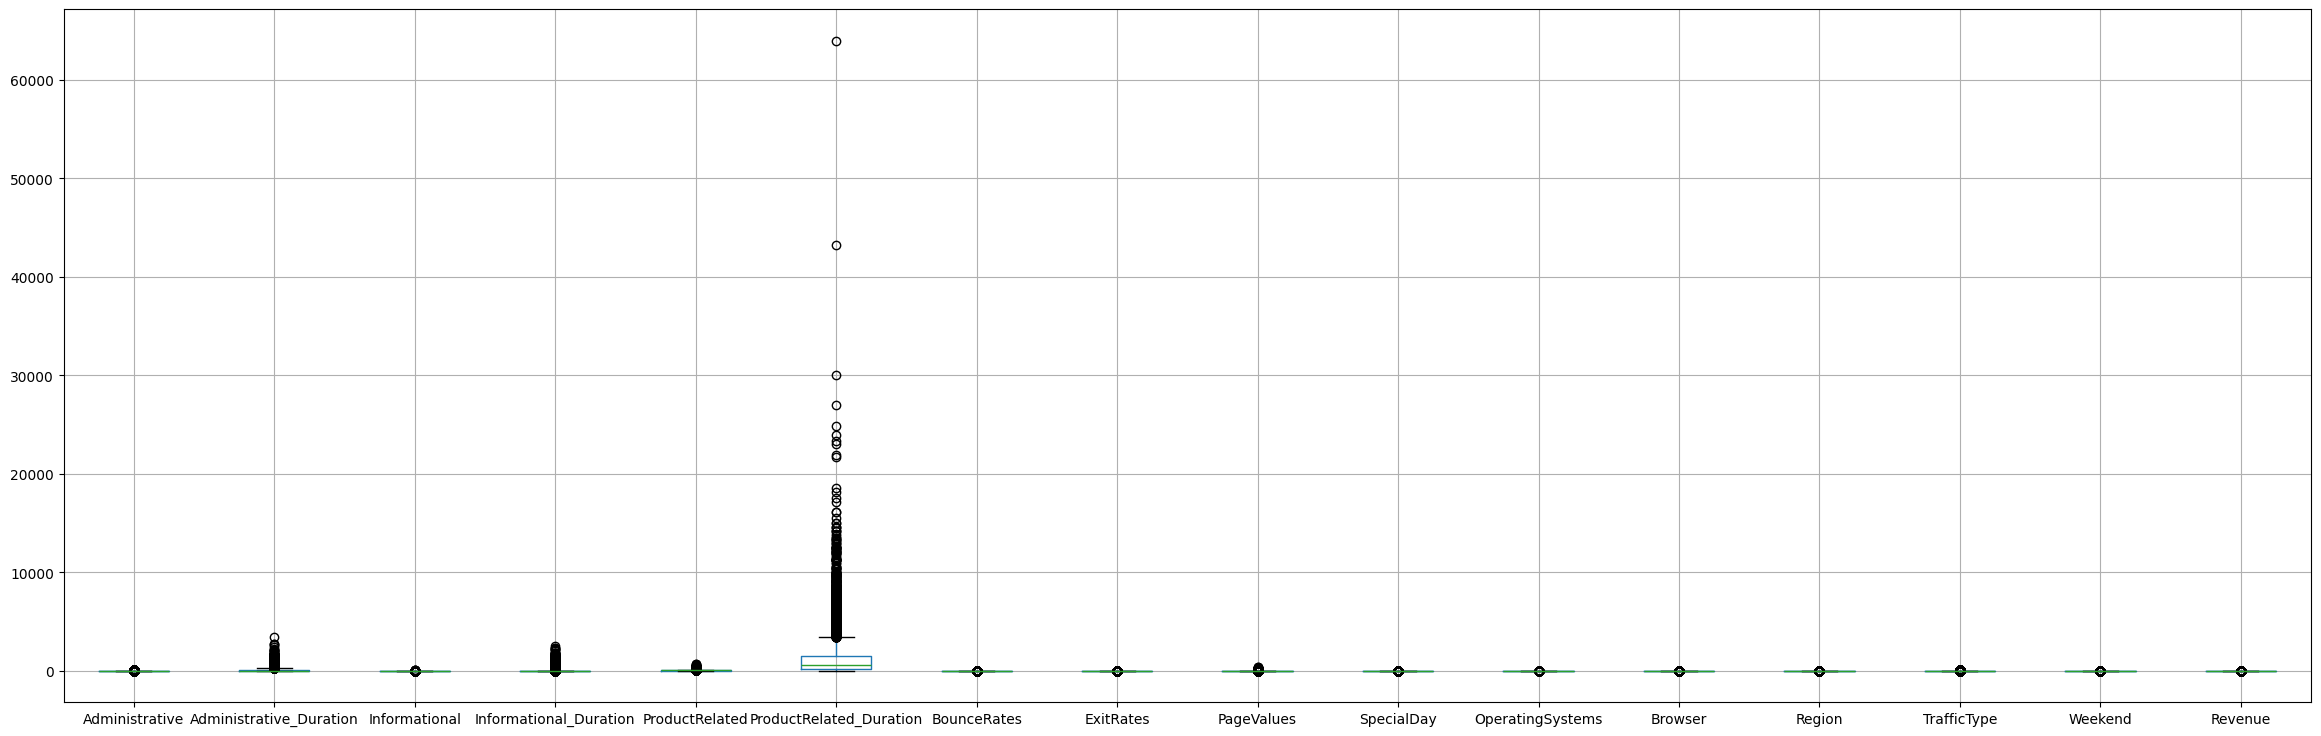

In [39]:
# check outliers
df.boxplot(figsize=(29,9))
plt.show()

In [46]:
# log transformation on ProductRelated_Duration for Reduces skewness and keeping the data intact
df['ProductRelated_Duration_log'] = np.log1p(df['ProductRelated_Duration'])

In [45]:
# Insight
# Outliers were retained because they represent real high-engagement user behavior, which is critical for conversion analysis.

## Analysis

In [56]:
# understand target variable
df['Revenue'].value_counts(normalize=True) * 100

Revenue
False    84.525547
True     15.474453
Name: proportion, dtype: float64

In [62]:
# Only ~15% of users convert while ~85% drop off,indicating a significant conversion gap.

In [54]:
# comapre buyers vs non buyers
df.groupby('Revenue')[['BounceRates']].mean()

,BounceRates
Revenue,
False,0.025317
True,0.005117


In [ ]:
# Users who convert have significantly lower bounce rates indicating that higher engagement and reduced early exits.

In [53]:
# page values with revenue
df.groupby('Revenue')[['PageValues']].mean()

,PageValues
Revenue,
False,1.975998
True,27.264518


In [63]:
# Users who convert have dramatically higher page values, making page value the strongest indicator of purchase intent

In [52]:
# total time spent of customer
df.groupby('Revenue')[['Administrative_Duration','Informational_Duration','ProductRelated_Duration']].mean()

,Administrative_Duration,Informational_Duration,ProductRelated_Duration
Revenue,,,
False,73.740111,30.236237,1069.987809
True,119.483244,57.611427,1876.209615


In [ ]:
#Converting users spend significantly more time across all page types—especially on product pages showing that deep engagement and purchase decisions.


In [58]:
# Compare outliers with Revenue
df.groupby('Revenue')[['ProductRelated_Duration']].mean()

,ProductRelated_Duration
Revenue,
False,1069.987809
True,1876.209615


In [64]:
# Users who convert spend ~75% more time on product-related pages, making product engagement a key driver of purchase behavior.

## Correlation analysis

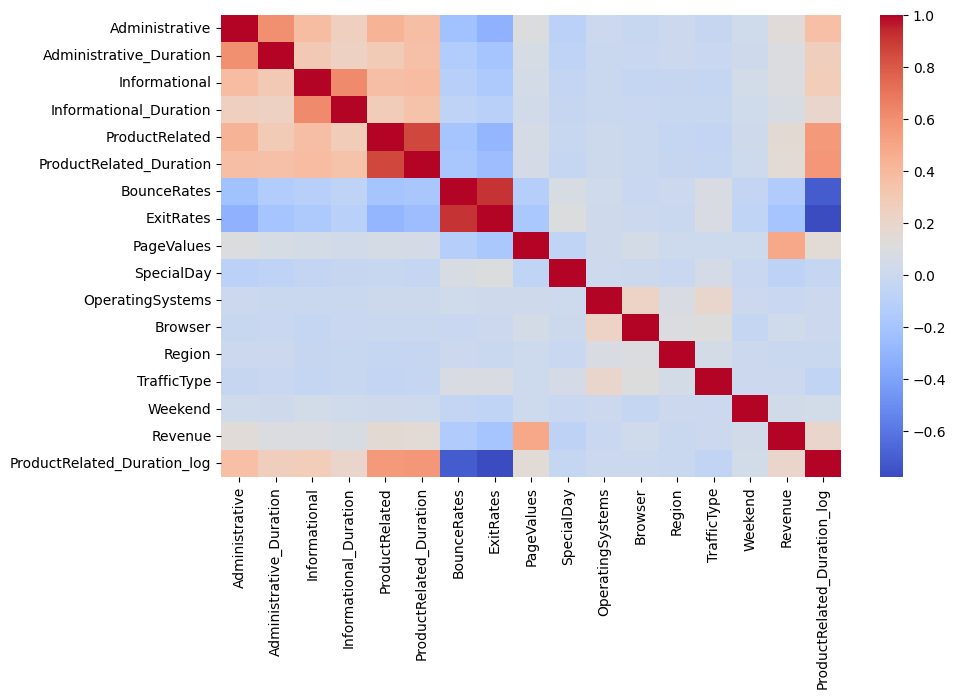

In [57]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.show()

In [ ]:
# User engagement metrics and page value are the strongest drivers of conversion, while high bounce and exit rates negatively impact purchase behavior.

## Visualization

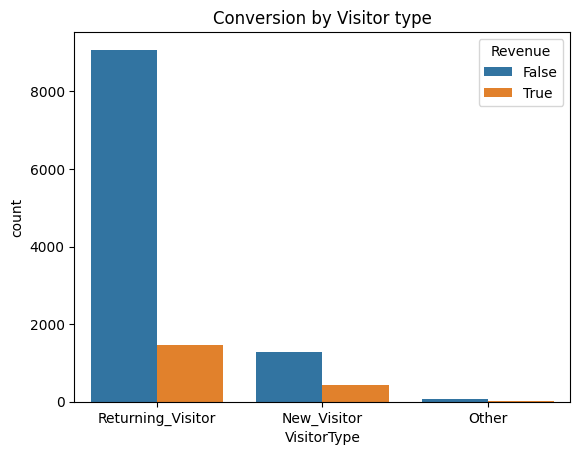

In [59]:
# coversion by visitor type
sns.countplot(x='VisitorType', hue='Revenue', data=df)
plt.title("Conversion by Visitor type")
plt.show()

In [ ]:
# Returning visitors contribute the majority of conversions, indicating that repeat users are far more likely to purchase than new visitors.

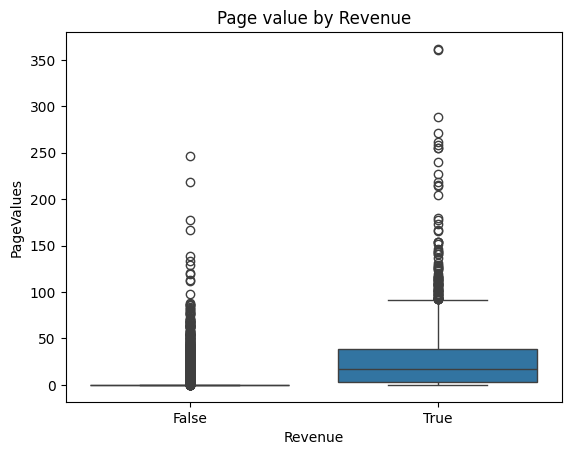

In [60]:
# page value by revenue
sns.boxplot(x='Revenue', y='PageValues', data=df)
plt.title("Page value by Revenue")
plt.show()

In [65]:
# Users who convert have significantly higher page values with a clear upward shift in distribution,
# confirming page value as a strong predictor of purchase intent.

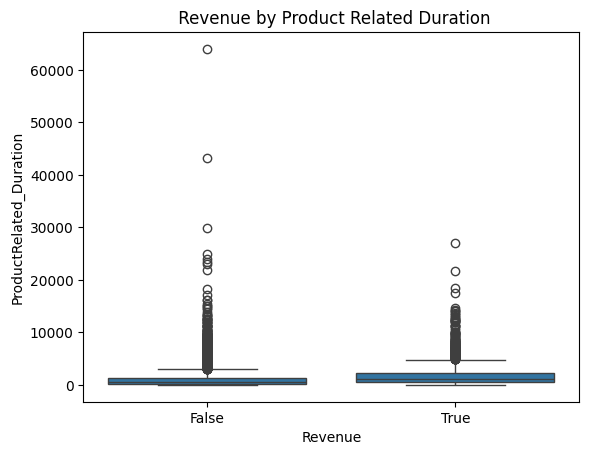

In [61]:
# revenue by product relates duration
sns.boxplot(x='Revenue', y='ProductRelated_Duration', data=df)
plt.title(" Revenue by Product Related Duration") 
plt.show()


In [ ]:
# Insight
# Users who spend significantly more time on product-related pages are much more likely to convert. 
# In fact, buyers spent around 75% more time compared to non-buyers, indicating that engagement is a key driver of purchase decisions.

## Feature Importance using Random Forest

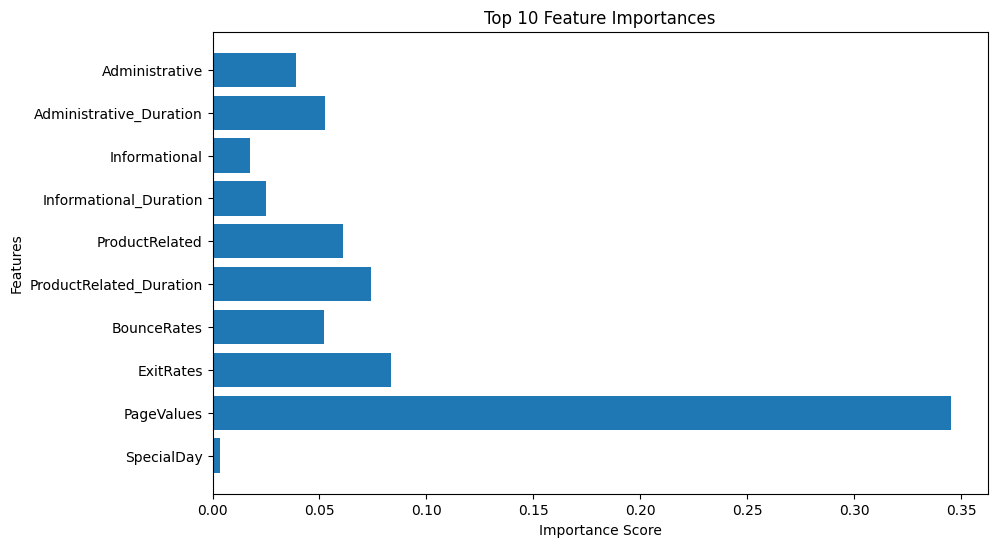

In [75]:
# Import required libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Separate features (X) and target (y)
X = df.drop('Revenue', axis=1)   # Independent variables
y = df['Revenue']                # Target variable (conversion)

# Convert categorical variables into numerical (one-hot encoding)
X = pd.get_dummies(X)

# Split data into training and testing sets , 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize Random Forest model
model = RandomForestClassifier(random_state=42)

# Train the model
model.fit(X_train, y_train)

# Get feature importance scores
importances = model.feature_importances_

# Plot feature importance (Top 10)
plt.figure(figsize=(10,6))
plt.barh(
    feature_importance_df['Feature'].head(10),
    feature_importance_df['Importance'].head(10)
)
plt.gca().invert_yaxis()  # Highest importance on top
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()




In [76]:
# Random Forest model identify the most important features influencing conversion. 
# The model assigns importance scores based on how much each feature contributes to prediction accuracy.

## Key Insights
1️⃣ Low Conversion Problem:
Only ~15% users convert → huge optimization opportunity

2️⃣ Engagement Drives Sales:
Buyers spend significantly more time, especially on product pages

3️⃣ Page Value is the Strongest Indicator:
High PageValues strongly correlate with purchase

4️⃣ Bounce Rate Hurts Conversion
High bounce rate users rarely purchase

5️⃣ Returning Users Convert More
Repeat visitors are more likely to buy

## Business Recommendations
Based on your analysis:

- Improve product page experience
- Reduce bounce rate (better UI/UX)
- Target high-engagement users
- Focus marketing on returning visitors
- Optimize high page-value pages
    
##  Conclusion
This project helps businesses understand customer behavior and provides actionable insights to increase conversion rates and revenue.